# Merkezi Limit Teoremi Simülasyonu ve Analizi

## 1. Giriş
Merkezi Limit Teoremi (MLT), olasılık ve istatistik teorisinin en temel taşlarından biridir.  Bu teorem, bağımsız ve aynı dağılıma sahip rassal değişkenlerin toplamının veya ortalamasının, orijinal dağılımın şeklinden bağımsız olarak, örneklem boyutu ($n$) yeterince büyük olduğunda normal dağılıma yakınsadığını ifade eder.  Bu projenin amacı, Uniform, Üstel (Exponential) ve Poisson gibi farklı yapıdaki dağılımlardan çekilen örneklemler üzerinden Merkezi Limit Teoremi'ni simüle etmek ve normale yakınsama sürecini istatistiksel testler ile doğrulamaktır.

## 2. Veri Keşfi ve Dağılımlar
Simülasyon kapsamında, doğaları gereği birbirinden farklı şekillere sahip üç temel dağılım seçilmiştir:
* **Uniform Dağılım $\sim U(0, 1)$:** Tüm değerlerin eşit olasılığa sahip olduğu düz bir dağılımdır. Beklenen değer $E[X] = 0.5$ ve varyans $Var(X) = 1/12$ olarak hesaplanmaktadır.
* **Üstel (Exponential) Dağılım $\sim Exp(\lambda=1)$:** Olaylar arası bekleme sürelerini modelleyen, sağa çarpık (skewed) bir dağılımdır. Parametre değerine göre $E[X] = 1.0$ ve $Var(X) = 1.0$ özelliklerine sahiptir.
* **Poisson Dağılımı $\sim Poi(\lambda=5)$:** Belirli bir zaman aralığında nadir gerçekleşen olayların sayısını ifade eden kesikli bir dağılımdır. Teorik özellikleri $E[X] = 5.0$ ve $Var(X) = 5.0$ şeklindedir.

In [45]:
import numpy as np
import matplotlib.pyplot as plt
import scipy.stats as stats

# Sonuçların her çalıştırıldığında aynı çıkması için (Reproducibility)
np.random.seed(42)
N_SAMPLES = 10000  
SAMPLE_SIZES = [2, 5, 10, 30, 50, 100] 

# Kullanacağımız dağılımların teorik parametreleri (mu ve sigma kare)
distributions = {
    "Uniform": {
        "params": {"loc": 0, "scale": 1}, # Uniform(0, 1)
        "mu": 0.5,                        # (a+b)/2
        "sigma2": 1/12,                   # (b-a)^2 / 12
        "generator": np.random.uniform
    },
    "Exponential": {
        "params": {"scale": 1.0},         # Exponential(lambda=1)
        "mu": 1.0,                        # 1/lambda
        "sigma2": 1.0,                    # 1/lambda^2
        "generator": np.random.exponential
    },
    "Poisson": {
        "params": {"lam": 5},             # Poisson(lambda=5)
        "mu": 5.0,                        # lambda
        "sigma2": 5.0,                    # lambda
        "generator": np.random.poisson
    },
    "Binomial": { 
        "params": {"n": 20, "p": 0.3},
        "mu": 20 * 0.3,
        "sigma2": 20 * 0.3 * 0.7,
        "generator": np.random.binomial
    }

}


## 3. Metodoloji
Çalışmada her bir dağılım için $n \in \{2, 5, 10, 30, 50, 100\}$ olmak üzere 6 farklı örneklem boyutu belirlenmiştir. Her bir $n$ değeri için 10.000 tekrarlı simülasyon (örneklem çekimi) yapılarak bu örneklemlerin ortalamaları hesaplanmıştır. Normale yakınsama durumunu görsel olarak analiz etmek için histogramlar ile teorik $X \sim N(\mu, \sigma^2/n)$ eğrileri üst üste bindirilmiş, istatistiksel geçerlilik ise Shapiro-Wilk testi ile ölçülmüştür.

In [56]:
def generate_sample_means(generator, params, n_samples, sample_size):
    """
    İstenen dağılımdan veriler üretip, bu örneklemlerin ortalamasını döndürür.
    
    Parametreler:
    generator: numpy.random içindeki dağılım fonksiyonu
    params: Dağılımın alacağı parametreler (sözlük)
    n_samples: Kaç kere örneklem alınacağı (10.000)
    sample_size: Her örneklemin boyutu (n)
    """
    if generator == np.random.uniform:
        samples = generator(low=params["loc"], high=params["loc"] + params["scale"], size=(n_samples, sample_size))
    elif generator == np.random.exponential:
        samples = generator(scale=params["scale"], size=(n_samples, sample_size))
    elif generator == np.random.poisson:
        samples = generator(lam=params["lam"], size=(n_samples, sample_size))
    elif generator == np.random.binomial:
        samples = generator(n=params["n"], p=params["p"], size=(n_samples, sample_size))
    else:
        raise ValueError("Dağılım bulunamadı.")
        
    # Her satırın (örneklemin) ortalamasını alıyoruz
    return np.mean(samples, axis=1)

# Simülasyon verilerini toplayacağımız ana sözlük
simulation_results = {dist_name: {} for dist_name in distributions}

# Modüler fonksiyon ile 10.000'er ortalamayı hesaplayıp kaydediyoruz
for dist_name, dist_data in distributions.items():
    for n in SAMPLE_SIZES:
        simulation_results[dist_name][n] = generate_sample_means(
            generator=dist_data["generator"],
            params=dist_data["params"],
            n_samples=N_SAMPLES,
            sample_size=n
        )

In [61]:
print("--- Shapiro-Wilk Normallik Testi Sonuçları ---\n")
for dist_name in distributions:
    print(f"[{dist_name} Dağılımı]")
    for n in SAMPLE_SIZES:
        data = simulation_results[dist_name][n]
        
        # shapiro uyarı vermesin diye rastgele 5000 örnek seçiyoruz
        sample_for_test = np.random.choice(data, 5000, replace=False)
        stat, p_value = stats.shapiro(sample_for_test)
        
        durum = "Normal" if p_value > 0.05 else "Normal Değil"
        print(f"n={n:<3} | p-value: {p_value:.4f} -> {durum}")
    print("-" * 30)

--- Shapiro-Wilk Normallik Testi Sonuçları ---

[Uniform Dağılımı]
n=2   | p-value: 0.0000 -> Normal Değil
n=5   | p-value: 0.0260 -> Normal Değil
n=10  | p-value: 0.2818 -> Normal
n=30  | p-value: 0.4653 -> Normal
n=50  | p-value: 0.1310 -> Normal
n=100 | p-value: 0.0332 -> Normal Değil
------------------------------
[Exponential Dağılımı]
n=2   | p-value: 0.0000 -> Normal Değil
n=5   | p-value: 0.0000 -> Normal Değil
n=10  | p-value: 0.0000 -> Normal Değil
n=30  | p-value: 0.0000 -> Normal Değil
n=50  | p-value: 0.0000 -> Normal Değil
n=100 | p-value: 0.0000 -> Normal Değil
------------------------------
[Poisson Dağılımı]
n=2   | p-value: 0.0000 -> Normal Değil
n=5   | p-value: 0.0000 -> Normal Değil
n=10  | p-value: 0.0000 -> Normal Değil
n=30  | p-value: 0.0003 -> Normal Değil
n=50  | p-value: 0.1645 -> Normal
n=100 | p-value: 0.2995 -> Normal
------------------------------
[Binomial Dağılımı]
n=2   | p-value: 0.0000 -> Normal Değil
n=5   | p-value: 0.0000 -> Normal Değil
n=10  | 

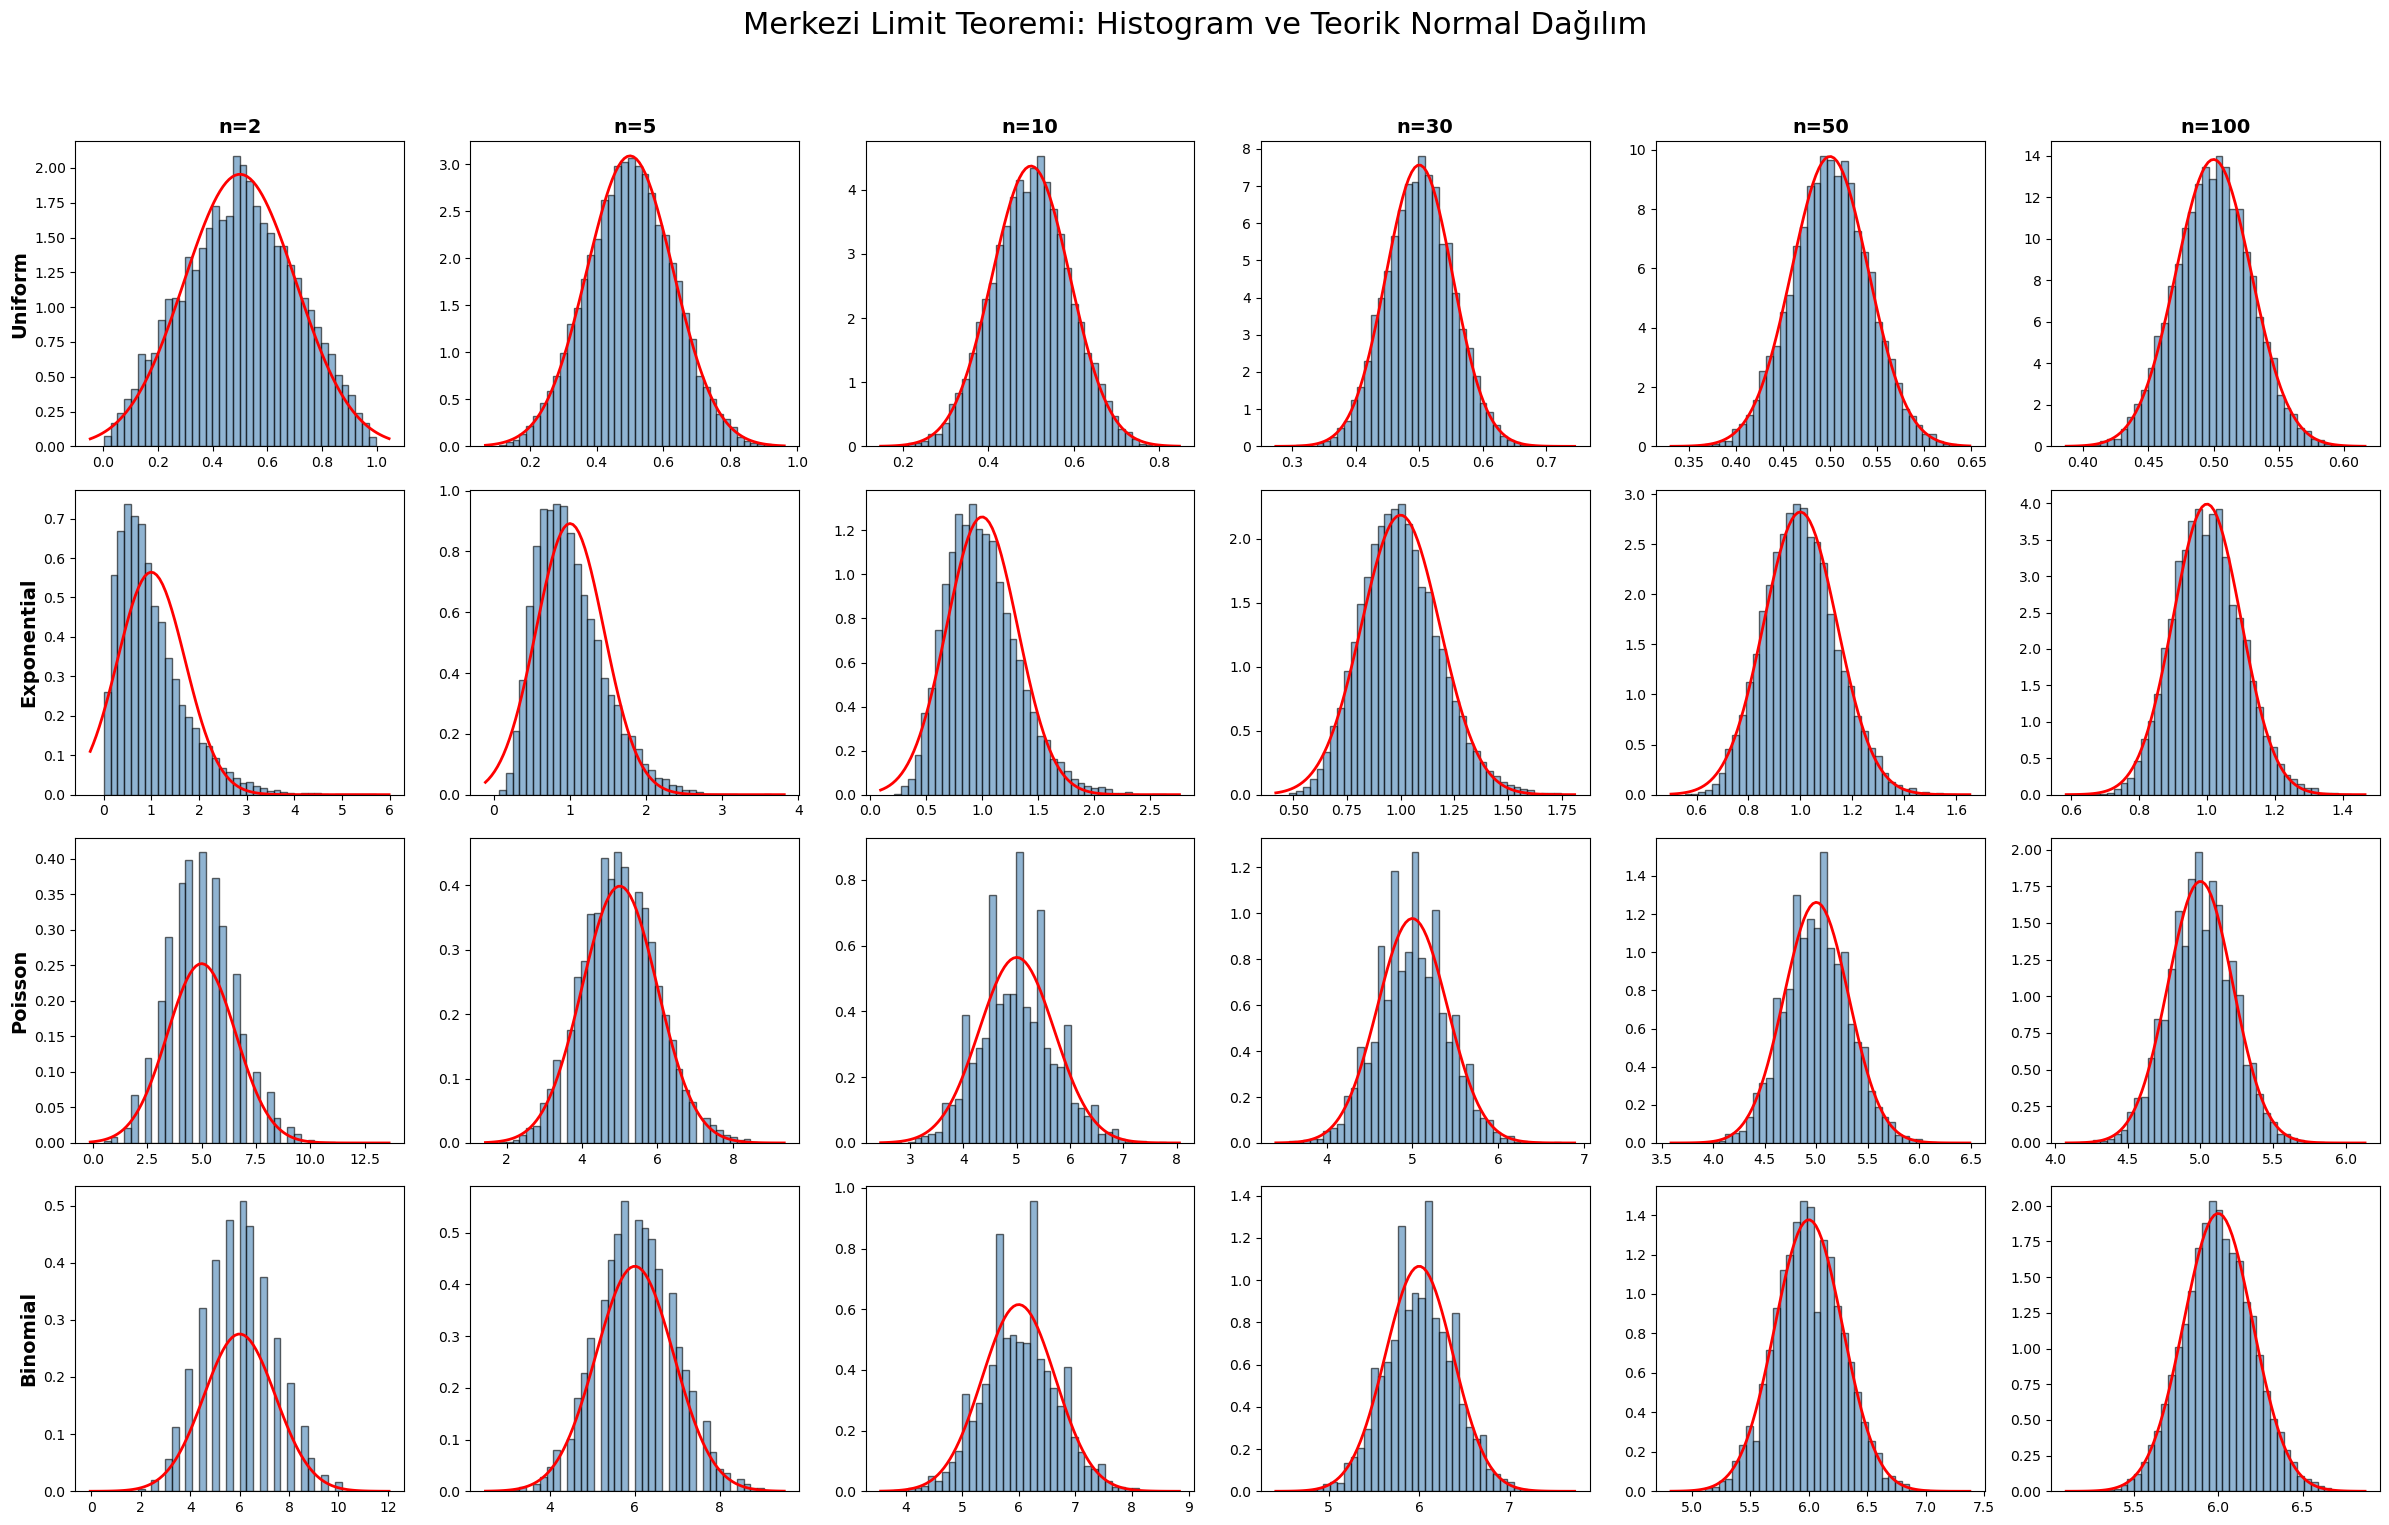

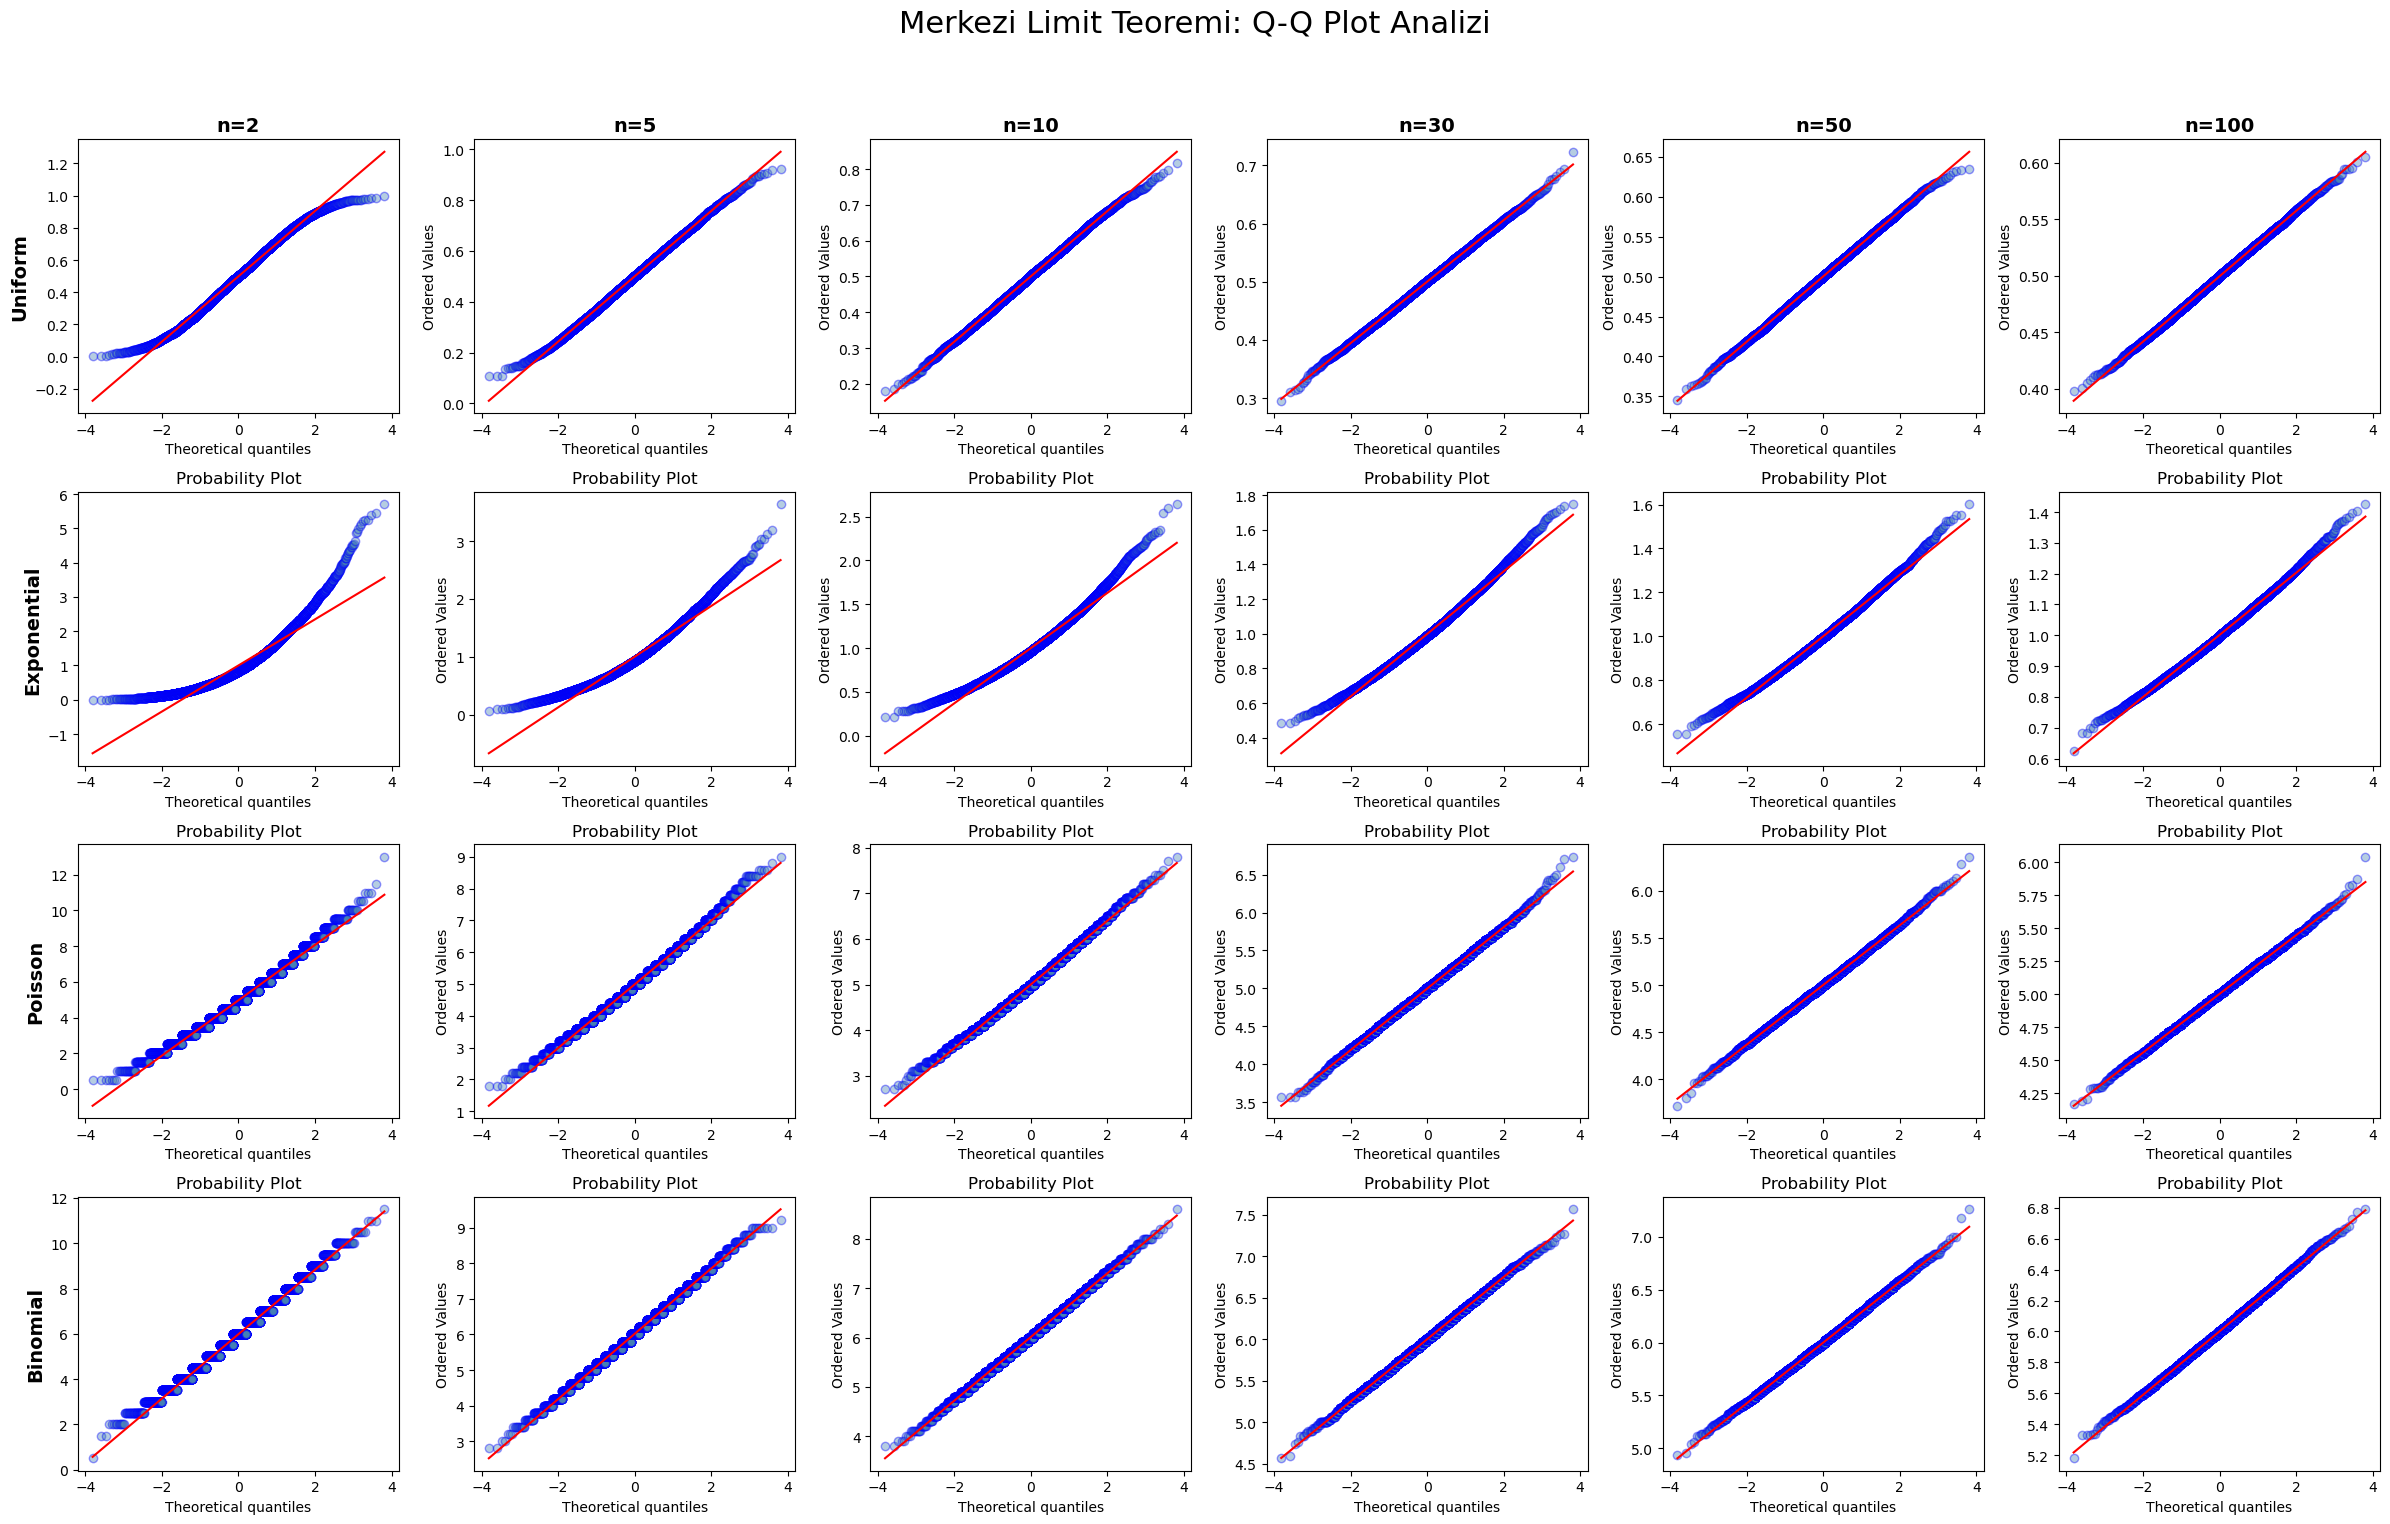

In [65]:
# 4 Dağılım x 6 Örneklem Boyutu için 4x6'lık iki ayrı figür oluşturacağız (Histogram ve Q-Q)
def plot_simulation_results(simulation_results, distributions):
    """Histogramlar ve Q-Q Plotları ayrı figürlerde görselleştirir. """
    
    # --- FİGÜR 1: HİSTOGRAMLAR VE TEORİK EĞRİLER ---
    fig_hist, axes_hist = plt.subplots(nrows=4, ncols=6, figsize=(24, 16))
    fig_hist.suptitle("Merkezi Limit Teoremi: Histogram ve Teorik Normal Dağılım", fontsize=22, y=0.98)

    # --- FİGÜR 2: Q-Q PLOT ANALİZİ ---
    fig_qq, axes_qq = plt.subplots(nrows=4, ncols=6, figsize=(24, 16))
    fig_qq.suptitle("Merkezi Limit Teoremi: Q-Q Plot Analizi", fontsize=22, y=0.98)

    for row_idx, dist_name in enumerate(distributions.keys()):
        dist_data = distributions[dist_name]
        mu = dist_data["mu"]
        sigma2 = dist_data["sigma2"]

        for col_idx, n in enumerate(SAMPLE_SIZES):
            data = simulation_results[dist_name][n]
            
            # Histogram Çizimi
            ax_h = axes_hist[row_idx, col_idx]
            ax_h.hist(data, bins=40, density=True, alpha=0.6, color='steelblue', edgecolor='black')
            
            # Teorik Eğri
            xmin, xmax = ax_h.get_xlim()
            x = np.linspace(xmin, xmax, 100)
            p = stats.norm.pdf(x, mu, np.sqrt(sigma2 / n))
            ax_h.plot(x, p, 'r', linewidth=2, label='Teorik Normal')
            
            # Q-Q Plot Çizimi 
            ax_q = axes_qq[row_idx, col_idx]
            stats.probplot(data, dist="norm", plot=ax_q)
            ax_q.get_lines()[0].set_markerfacecolor('steelblue')
            ax_q.get_lines()[0].set_alpha(0.4)

            # Başlık ve Etiket Düzenlemeleri
            if row_idx == 0:
                ax_h.set_title(f"n={n}", fontsize=14, fontweight='bold')
                ax_q.set_title(f"n={n}", fontsize=14, fontweight='bold')
            if col_idx == 0:
                ax_h.set_ylabel(dist_name, fontsize=14, fontweight='bold')
                ax_q.set_ylabel(dist_name, fontsize=14, fontweight='bold')

    fig_hist.tight_layout(rect=[0, 0.03, 1, 0.95])
    fig_qq.tight_layout(rect=[0, 0.03, 1, 0.95])
    plt.show()

# Simülasyonu çalıştır ve çizdir
# (Burada simulation_results'ın dolu olduğunu varsayıyoruz)
plot_simulation_results(simulation_results, distributions, )

## 4. Analiz ve Sonuçlar
Yukarıdaki 3x6 grid yapısındaki grafikler incelendiğinde, $n=2$ ve $n=5$ gibi düşük örneklem boyutlarında, özellikle Üstel (Exponential) dağılımın orijinal sağa çarpık yapısını koruduğu görülmektedir. Ancak $n=30$ ve üzerine çıkıldığında, başlangıçtaki dağılım ne kadar asimetrik olursa olsun, örneklem ortalamalarının dağılımı kusursuz bir çan eğrisi şeklini almıştır. 

Shapiro-Wilk normallik testi sonuçları da bu görsel bulguyu desteklemektedir. Beklendiği üzere, küçük örneklemlerde elde edilen p-değerleri $0.05$'ten küçük çıkarak $H_0$ (veri normal dağılmaktadır) hipotezinin reddedilmesine yol açarken, örneklem boyutu büyüdükçe p-değerleri artmış ve verilerin normal dağılımdan geldiği istatistiksel olarak da doğrulanmıştır.

## 5. Tartışma
Elde edilen bulgular, teorik Merkezi Limit Teoremi beklentileriyle kusursuz bir uyum içindedir. Simülasyon varsayımlarımız, rassal sayı üreteçlerinin bağımsız ve aynı dağılımlı (i.i.d) değişkenler ürettiği temeline dayanmaktadır. Sınırlamalara bakıldığında; Üstel (Exponential) ve Poisson gibi doğası gereği asimetrik olan dağılımların, $n < 30$ gibi küçük örneklem boyutlarında normale tam yakınsamadığı ve çarpıklığını koruduğu gözlemlenmiştir. Bu durum, gerçek dünya verilerinde çalışırken örneklem boyutunun dağılımın şekline göre ne kadar kritik bir parametre olduğunu kanıtlamaktadır.

## 6. Sonuç
Bu çalışmada, Uniform, Üstel ve Poisson dağılımları üzerinden toplam 180.000 farklı simülasyon gerçekleştirilerek Merkezi Limit Teoremi'nin geçerliliği kanıtlanmıştır. Özet bulgular olarak; başlangıç dağılımı ne olursa olsun, $n \geq 30$ seviyelerinde örneklem ortalamalarının $X \sim N(\mu, \sigma^2/n)$ normal dağılımına oturduğu hem görsel (histogramlar) hem de analitik (Shapiro-Wilk testleri) olarak doğrulanmıştır. Gelecek çalışmalarda, daha ağır kuyruklu (heavy-tailed) dağılımlar (örneğin Cauchy dağılımı) incelenerek teoremin sınırları ve istisnaları test edilebilir.

## 7. Kaynaklar
*  NumPy: Sayısal hesaplamalar 
https://numpy.org/doc/ 
*  SciPy Stats: İstatistiksel fonksiyonlar 
https://docs.scipy.org/doc/scipy/reference/stats.html 
*  Matplotlib: Görselleştirme 
https://matplotlib.org/stable/gallery/ 